| Scaler         | Uses         | Sensitive to Outliers | Typical Range |
| -------------- | ------------ | --------------------- | ------------- |
| StandardScaler | Mean + Std   | Yes                   | Unbounded     |
| MinMaxScaler   | Min + Max    | Very Yes              | 0–1           |
| RobustScaler   | Median + IQR | No                    | Unbounded     |
---

# When should you choose each?
---
 ## StandardScaler

Use when

* Data is approximately normal
* No extreme outliers
* Linear models
* PCA
* SVM
* KMeans
---
## MinMaxScaler

Use when

* Neural networks
* Pixel values
* Features already have meaningful minimum/maximum bounds
---
##RobustScaler

Use when

* Lots of outliers
* Financial data
* Sensor measurements
* Income/salary datasets

---
---
| Model                         | Scaling Needed? | Why                                           |
| ----------------------------- | --------------- | --------------------------------------------- |
| Linear Regression             | Yes             | Gradient optimization and coefficient balance |
| Logistic Regression           | Yes             | Same reasons as linear regression             |
| SVM                           | Yes             | Distance-based optimization                   |
| KNN                           | Yes             | Distance-based algorithm                      |
| K-Means                       | Yes             | Distance-based clustering                     |
| PCA                           | Yes             | Based on feature variance                     |
| Neural Networks               | Yes             | Faster, more stable optimization              |
| Decision Tree                 | No              | Uses threshold comparisons only               |
| Random Forest                 | No              | Collection of decision trees                  |
| XGBoost / LightGBM / CatBoost | No              | Gradient-boosted decision trees               |


---
# **Q.  visualise how each scaler transforms the same data**
---

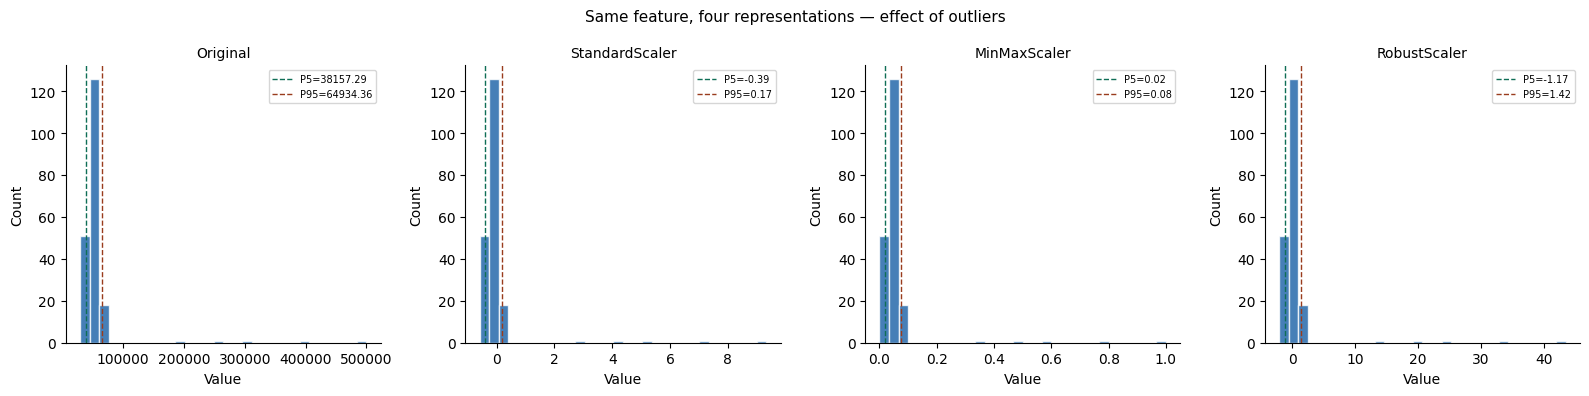

StandardScaler    : bulk range = [-0.583, 5.118]  spread = 5.701
MinMaxScaler      : bulk range = [0.000, 0.575]  spread = 0.575
RobustScaler      : bulk range = [-2.055, 24.143]  spread = 26.197


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

np.random.seed(42)
n = 200

# Feature with outliers — realistic income column
income = np.concatenate([
    np.random.normal(50000, 8000, n-5),   # most people
    np.array([200000, 250000, 300000, 400000, 500000])  # 5 outliers
])

scalers = {
    'Original':     None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Same feature, four representations — effect of outliers", fontsize=11)

for ax, (name, scaler) in zip(axes, scalers.items()):
    if scaler is None:
        vals = income
    else:
        vals = scaler.fit_transform(income.reshape(-1,1)).flatten()

    ax.hist(vals, bins=30, color='#185FA5', edgecolor='white', alpha=0.8)
    ax.set_title(name, fontsize=10, fontweight='500')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

    # Mark where the bulk of data is
    p5, p95 = np.percentile(vals, [5, 95])
    ax.axvline(p5,  color='#0F6E56', lw=1, linestyle='--', label=f'P5={p5:.2f}')
    ax.axvline(p95, color='#993C1D', lw=1, linestyle='--', label=f'P95={p95:.2f}')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('scaler_comparison.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()

# Quantify the compression effect
for name, scaler in scalers.items():
    if scaler is None: continue
    vals = scaler.fit_transform(income.reshape(-1,1)).flatten()
    bulk = vals[vals < np.percentile(vals, 99)]   # ignore top 1%
    print(f"{name:<18}: bulk range = [{bulk.min():.3f}, {bulk.max():.3f}]  "
          f"spread = {bulk.max()-bulk.min():.3f}")

#Insights:
---
> Min Max Scalar squashed heavy for the outlier. Best choice is robust scalar as it is well spreaded for outliers.

---
# **Q.  the correct Pipeline pattern with scaler (no leakage)**
---

In [2]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.datasets import load_breast_cancer
import numpy as np

X, y = load_breast_cancer(return_X_y=True)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Try all three scalers, correct Pipeline pattern ──────────────────────────
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
}

print("Breast cancer dataset — comparing scalers with LogisticRegression")
print(f"\n{'Scaler':<18} {'Test acc':>9} {'Train acc':>10} {'Gap':>7}")
print("-" * 48)

for name, scaler in scalers.items():
    pipe = Pipeline([
        ('scaler', scaler),            # ← scaler fits only on train fold
        ('model',  LogisticRegression(max_iter=1000, random_state=42))
    ])
    cv = cross_validate(pipe, X, y, cv=skf, scoring='accuracy',
                        return_train_score=True)
    te = cv['test_score'].mean()
    tr = cv['train_score'].mean()
    print(f"{name:<18} {te:>9.4f} {tr:>10.4f} {tr-te:>7.4f}")

print("\n--- Why the scaler must be INSIDE the Pipeline ---")
print("If you scale BEFORE the CV loop:")
print("  scaler.fit_transform(X_all)  ← uses ALL rows including val fold")
print("  Validation statistics leaked into scaler params")
print()
print("If you use Pipeline([('scaler', ...), ('model', ...)]):")
print("  In each CV fold → scaler.fit(X_train_fold)  ← only 80% of data")
print("                  → scaler.transform(X_val_fold)  ← honest transform")
print("  No information from val fold touches the scaler.")

Breast cancer dataset — comparing scalers with LogisticRegression

Scaler              Test acc  Train acc     Gap
------------------------------------------------
StandardScaler        0.9737     0.9881  0.0145
MinMaxScaler          0.9649     0.9692  0.0044
RobustScaler          0.9789     0.9899  0.0110

--- Why the scaler must be INSIDE the Pipeline ---
If you scale BEFORE the CV loop:
  scaler.fit_transform(X_all)  ← uses ALL rows including val fold
  Validation statistics leaked into scaler params

If you use Pipeline([('scaler', ...), ('model', ...)]):
  In each CV fold → scaler.fit(X_train_fold)  ← only 80% of data
                  → scaler.transform(X_val_fold)  ← honest transform
  No information from val fold touches the scaler.


---
# **Q.  Build a ColumnTransformer that applies different scalers to different feature groups — RobustScaler to outlier-prone columns, StandardScaler to normal ones, and no scaling to binary features.**
---


In [3]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

np.random.seed(42)
n = 300

# Realistic mixed dataset
df = pd.DataFrame({
    'income':       np.concatenate([np.random.normal(50000,8000,n-5), [500000]*5]),  # outliers
    'age':          np.random.normal(40, 10, n),       # roughly normal
    'credit_score': np.random.normal(650, 80, n),      # roughly normal
    'debt_ratio':   np.random.exponential(0.3, n),     # skewed, outliers
    'is_employed':  np.random.randint(0, 2, n),        # binary
    'has_degree':   np.random.randint(0, 2, n),        # binary
})
y = ((df['income'] > 55000) & (df['credit_score'] > 650)).astype(int)

# Group features by their scaling needs
robust_cols    = ['income', 'debt_ratio']          # outliers likely
standard_cols  = ['age', 'credit_score']            # roughly normal
passthrough_cols = ['is_employed', 'has_degree']   # binary — leave as is

preprocessor = ColumnTransformer(transformers=[
    ('robust',    RobustScaler(),   robust_cols),
    ('standard',  StandardScaler(), standard_cols),
    ('passthrough', 'passthrough',  passthrough_cols),
])

pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Compare: ColumnTransformer vs naive (same scaler for everything)
pipe_naive = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
s_smart = cross_val_score(pipe,       df[robust_cols+standard_cols+passthrough_cols], y, cv=skf, scoring='f1')
s_naive = cross_val_score(pipe_naive, df[robust_cols+standard_cols+passthrough_cols], y, cv=skf, scoring='f1')

print(f"Naive (StandardScaler everywhere): F1 = {s_naive.mean():.4f} ± {s_naive.std():.4f}")
print(f"Smart ColumnTransformer:           F1 = {s_smart.mean():.4f} ± {s_smart.std():.4f}")

# Show what the preprocessor produces
X_sample = df[robust_cols+standard_cols+passthrough_cols].head(3)
preprocessor.fit(df[robust_cols+standard_cols+passthrough_cols])
X_transformed = preprocessor.transform(X_sample)
out_cols = robust_cols + standard_cols + passthrough_cols
print(f"\nSample transformed output (3 rows × {X_transformed.shape[1]} features):")
print(pd.DataFrame(X_transformed, columns=out_cols).round(3).to_string())

Naive (StandardScaler everywhere): F1 = 0.2727 ± 0.2282
Smart ColumnTransformer:           F1 = 0.6342 ± 0.1574

Sample transformed output (3 rows × 6 features):
   income  debt_ratio    age  credit_score  is_employed  has_degree
0   0.328      -0.456 -0.711        -0.586          1.0         1.0
1  -0.151       1.209  0.945        -0.345          1.0         1.0
2   0.441       1.147  0.329        -1.058          0.0         0.0
